First 5 rows of dataset

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Mean of each column
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

Standard Deviation of each column
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

Mean for each species
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.5

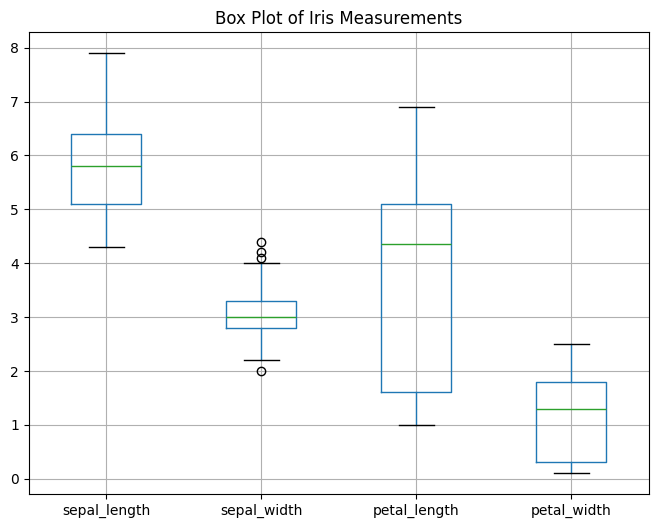

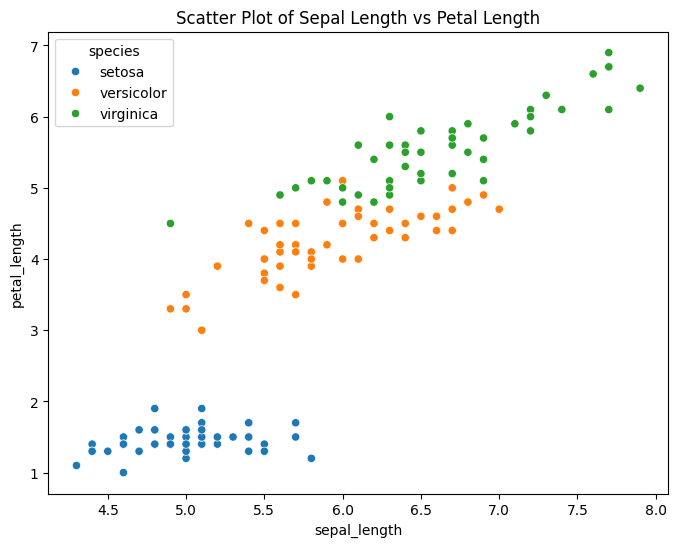

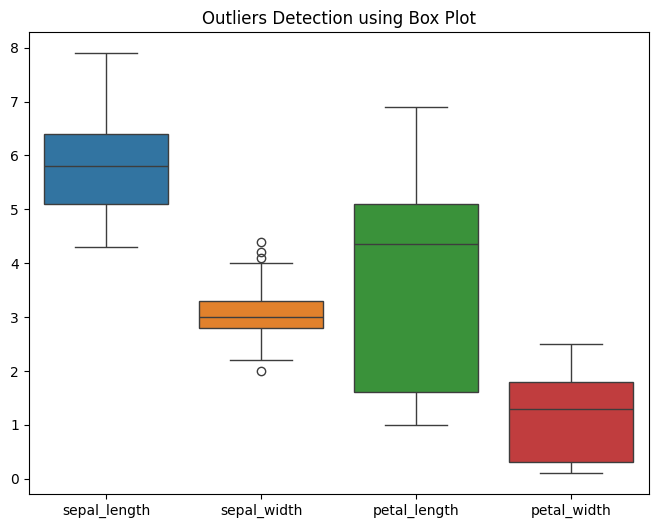

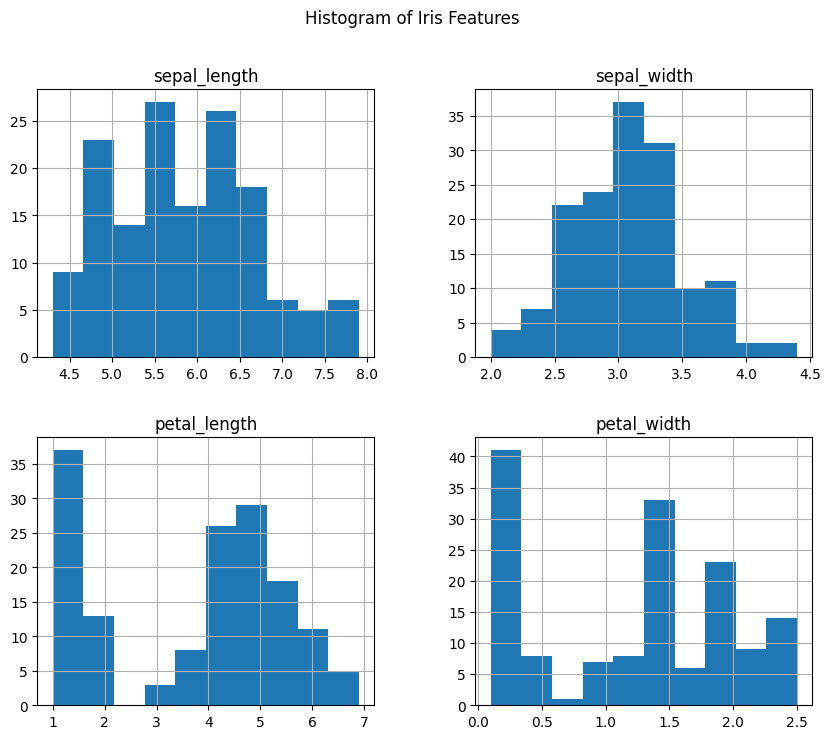

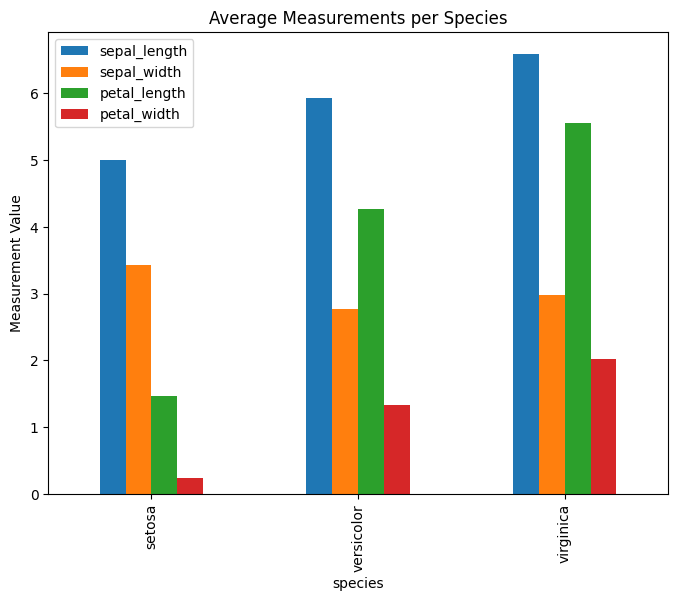

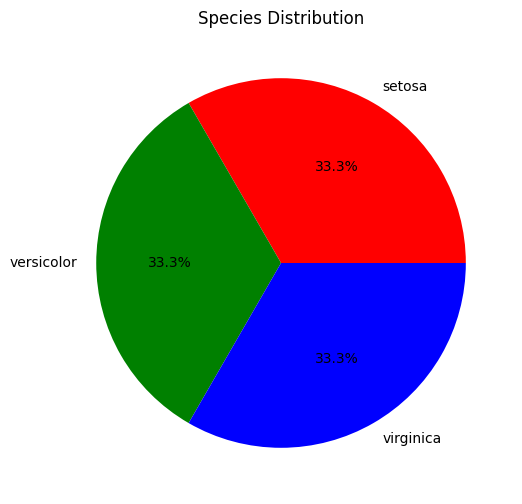

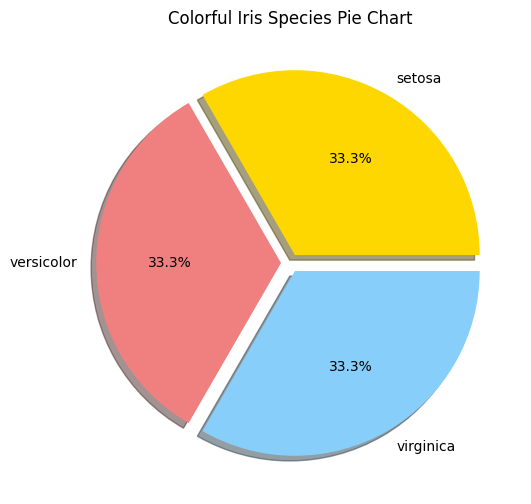

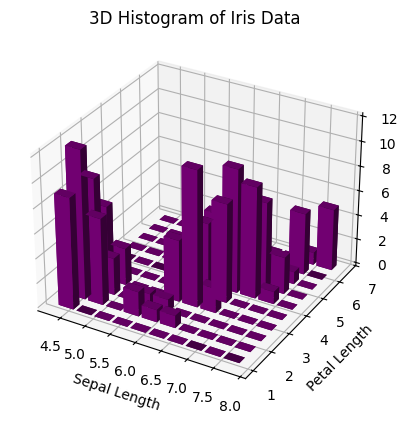

In [1]:
# ==========================
# IRIS DATASET ASSIGNMENT
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D

# --------------------------
# Load Iris Dataset
# --------------------------

iris = load_iris()

df = pd.DataFrame(iris.data, columns=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
])

df["species"] = iris.target
df["species"] = df["species"].map({
    0:"setosa",
    1:"versicolor",
    2:"virginica"
})

print("First 5 rows of dataset\n")
print(df.head())

# --------------------------
# Mean and Standard Deviation (Overall)
# --------------------------

print("\nMean of each column")
print(df.iloc[:,:4].mean())

print("\nStandard Deviation of each column")
print(df.iloc[:,:4].std())

# --------------------------
# Mean and STD for each species
# --------------------------

print("\nMean for each species")
print(df.groupby("species").mean())

print("\nStandard deviation for each species")
print(df.groupby("species").std())

# ==========================
# a) Data Distribution
# ==========================

# Box Plot
plt.figure(figsize=(8,6))
df.boxplot()
plt.title("Box Plot of Iris Measurements")
plt.show()

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot of Sepal Length vs Petal Length")
plt.show()

# ==========================
# b) Find Outliers using Box Plot
# ==========================

plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.title("Outliers Detection using Box Plot")
plt.show()

# ==========================
# c) Histogram, Bar Chart, Pie Chart
# ==========================

# Histogram
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Iris Features")
plt.show()

# Bar Chart (Average measurements)
means = df.groupby("species").mean()

means.plot(kind="bar", figsize=(8,6))
plt.title("Average Measurements per Species")
plt.ylabel("Measurement Value")
plt.show()

# Pie Chart (Species Distribution)
species_count = df["species"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(species_count, labels=species_count.index,
        autopct='%1.1f%%', colors=['red','green','blue'])
plt.title("Species Distribution")
plt.show()

# ==========================
# d) Pie Chart + 3D Histogram
# ==========================

# Colorful Pie Chart
plt.figure(figsize=(6,6))
plt.pie(species_count,
        labels=species_count.index,
        autopct='%1.1f%%',
        colors=['gold','lightcoral','lightskyblue'],
        explode=(0.05,0.05,0.05),
        shadow=True)

plt.title("Colorful Iris Species Pie Chart")
plt.show()

# 3D Histogram
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges, yedges = np.histogram2d(
    df["sepal_length"],
    df["petal_length"],
    bins=10
)

xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1])
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.3 * np.ones_like(zpos)
dz = hist.flatten()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='purple')

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Petal Length')
ax.set_zlabel('Frequency')

plt.title("3D Histogram of Iris Data")
plt.show()

First 5 rows of dataset
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Slope (m): 1.8339625990203465
Intercept (b): -6.927127731475695
R2 Score: 0.8181245472591437


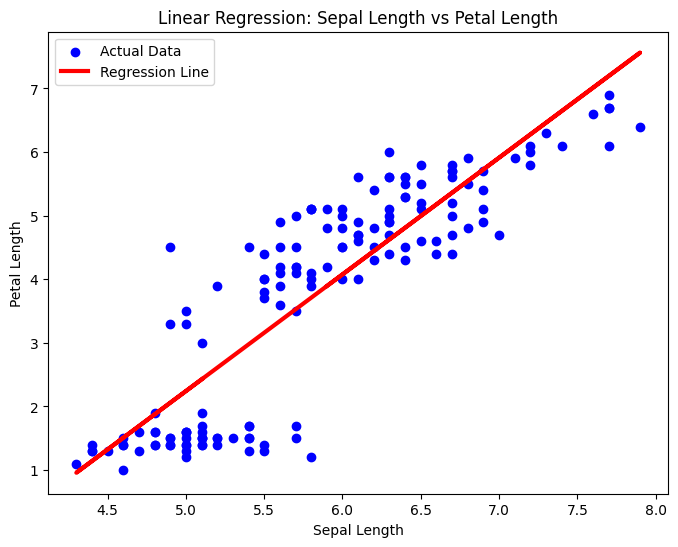

In [2]:
# =========================
# REGRESSION ANALYSIS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# -------------------------
# Load Dataset
# -------------------------

iris = load_iris()

df = pd.DataFrame(iris.data, columns=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
])

print("First 5 rows of dataset")
print(df.head())

# -------------------------
# Select Variables
# -------------------------

X = df[["sepal_length"]]   # independent variable
y = df["petal_length"]     # dependent variable

# -------------------------
# Train Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Train Regression Model
# -------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------

y_pred = model.predict(X_test)

print("\nSlope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

# -------------------------
# Accuracy
# -------------------------

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

# -------------------------
# Plot Regression Line
# -------------------------

plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue', label="Actual Data")

plt.plot(
    X,
    model.predict(X),
    color='red',
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Linear Regression: Sepal Length vs Petal Length")

plt.legend()

plt.show()

First 5 rows of dataset
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


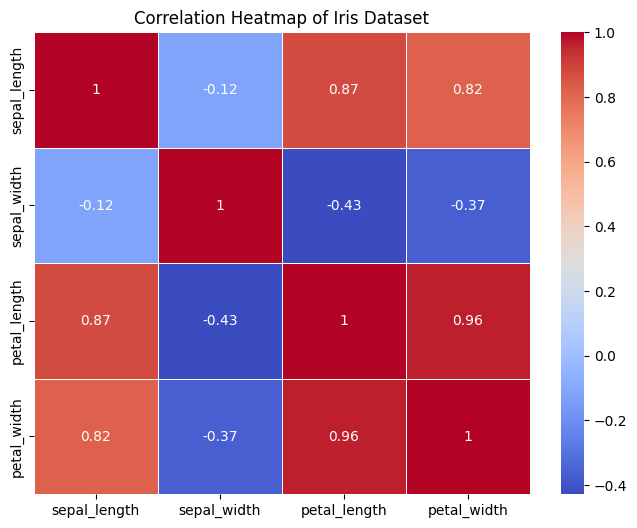

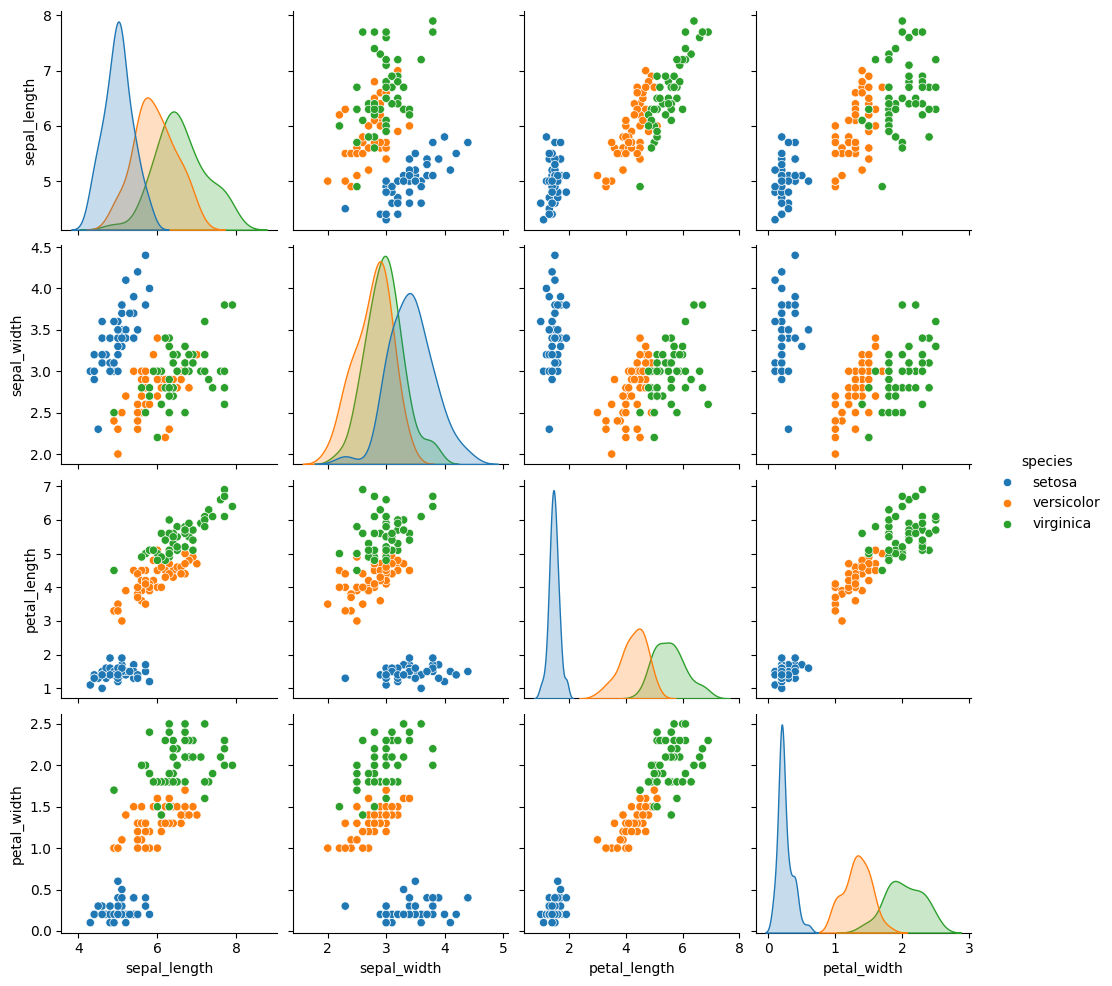


ANOVA Result
F-statistic: 119.26450218450468
p-value: 1.6696691907693826e-31
Result: Significant difference between groups


In [3]:
# ===============================
# CORRELATION MATRIX + ANOVA
# ===============================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from scipy import stats

# ------------------------------
# Load Dataset
# ------------------------------

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=["sepal_length","sepal_width","petal_length","petal_width"]
)

df["species"] = iris.target
df["species"] = df["species"].map({
    0:"setosa",
    1:"versicolor",
    2:"virginica"
})

print("First 5 rows of dataset")
print(df.head())

# ===============================
# Correlation Matrix
# ===============================

corr_matrix = df.iloc[:,:4].corr()

print("\nCorrelation Matrix")
print(corr_matrix)

# ===============================
# a) Correlation Plot (Heatmap)
# ===============================

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Iris Dataset")
plt.show()

# ===============================
# Scatterplot Matrix
# ===============================

sns.pairplot(df, hue="species")

plt.show()

# ===============================
# b) ANOVA (Analysis of Variance)
# ===============================

setosa = df[df["species"]=="setosa"]["sepal_length"]
versicolor = df[df["species"]=="versicolor"]["sepal_length"]
virginica = df[df["species"]=="virginica"]["sepal_length"]

f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)

print("\nANOVA Result")
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference between groups")
else:
    print("Result: No significant difference between groups")